In [1]:
%cd ..

/Users/eli/AnacondaProjects/captcha-numpyro


In [2]:
import jax
jax.config.update("jax_enable_x64", True)          # every check here is exact
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import rootutils

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)

from src.data.dictionary import ShapeDictionary
from src.distributions.layers import (POTENTIAL_EDGE_ALPHA, AlphaFormat, Layer)
from src.distributions.spatial import (CompleteGaussianMrf,
                                       LocallyScaledGaussianMrf,
                                       PartitionedGaussianMrf,
                                       SecondOrderGaussianMrf)
from src.model.model import _ink_kernel, _stamp


shape_dict = ShapeDictionary.load("data/captcha_sandbox/dictionary")
GLYPHS = list(shape_dict.targets.values())
KERNEL = _ink_kernel(shape_dict.shapes)
print(f"{len(GLYPHS)} glyphs, kernel {KERNEL.shape[:2]}")

def colorbar(axis, figure, img):
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(axis)
    colorbar_axis = divider.append_axes("right", size="5%", pad=0.05)
    figure.colorbar(img, cax=colorbar_axis)

def show(axis, img, title, **kw):
    im = axis.imshow(np.asarray(img), **kw)
    axis.set_title(title, fontsize=9)
    axis.set_xticks([]); axis.set_yticks([])
    return im

def stamp_alpha(glyph, y, x, size, spikes=1.):
    # Coverage of one glyph stamped with its centre at (y, x).
    counts = np.zeros((1, size, size, len(GLYPHS)))
    counts[0, y, x, GLYPHS.index(f"{glyph}_42")] = spikes
    depth = jnp.clip(_stamp(jnp.asarray(counts), KERNEL), 0.0, None)[0, ..., 3]
    return -jnp.expm1(-depth)


36 glyphs, kernel (38, 26)


## 1. The algebra

Two glyphs that genuinely overlap, so a count of 2 is exercised. Colour is
stored premultiplied by alpha, which is why `over` and `add` are linear in the
stored channels with no division and no special case at `alpha == 0`.

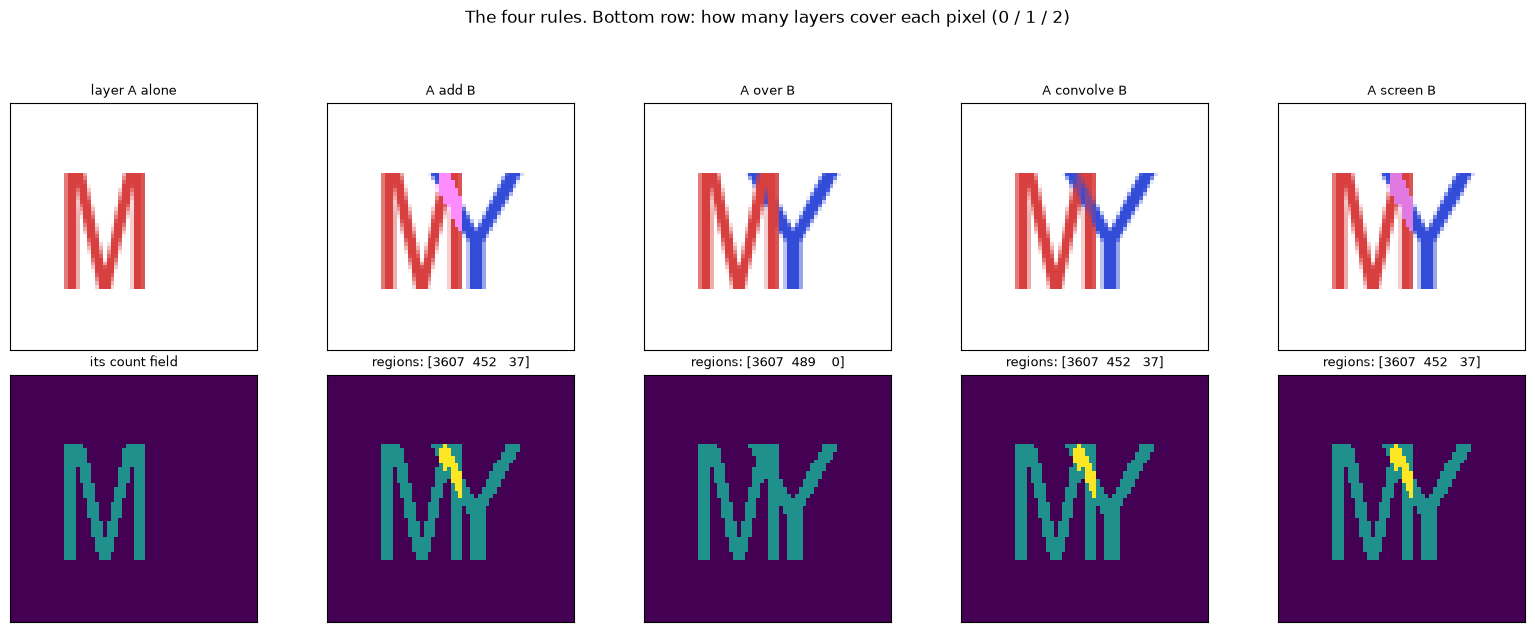

In [3]:
S = 64
red, blue = jnp.array([0.85, 0.25, 0.25]), jnp.array([0.20, 0.30, 0.85])
A = Layer.colored_mask(stamp_alpha("M", 32, 24, S, spikes=1.), red)
B = Layer.colored_mask(stamp_alpha("Y", 32, 38, S, spikes=1.), blue)

composites = {
    "add": A + B,
    "over": A @ B,
    "convolve": A * B,
    "screen": A | B,
}

fig, ax = plt.subplots(2, 5, figsize=(16, 6.4))
show(ax[0, 0], np.clip(A.over_background(), 0, 1), "layer A alone")
show(ax[1, 0], A.count, "its count field", cmap="viridis", vmin=0, vmax=2)
for col, rule in enumerate(composites.keys(), start=1):
    L = composites[rule]
    show(ax[0, col], np.clip(L.over_background(), 0, 1), f"A {rule} B")
    show(ax[1, col], L.count, f"regions: {np.asarray(L.region_sizes())}",
         cmap="viridis", vmin=0, vmax=2)
fig.suptitle("The four rules. Bottom row: how many layers cover each pixel "
             "(0 / 1 / 2)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.93));

In [4]:
Sm = 48

CANONICAL_ALPHA = jnp.moveaxis(
    -jnp.expm1(-KERNEL[..., 3, :]), -1, 0
)
CANONICAL_DEPTH = KERNEL[..., 3:4, :]
CANONICAL_HUE = jnp.where(
    CANONICAL_DEPTH > 1e-6,
    KERNEL[..., :3, :] / jnp.clip(CANONICAL_DEPTH, 1e-6, None),
    1.0,
)
COLOR_FIELD_BOND_PRECISION = 4.0
COLOR_FIELD_ELEMENT_PRECISION = 1.0
K = len(GLYPHS)
KAPPA = 8000.0
RATE = 4.0 / (Sm * Sm * K)
TAU = 69.4
TRUE = ("M", 24, 24)
TRUE_COLOR = jnp.array([0.20, 0.24, 0.55])

GLYPH_COLOR_PRIOR = SecondOrderGaussianMrf(
    jnp.zeros((*KERNEL.shape[:2], 3)),
    COLOR_FIELD_ELEMENT_PRECISION * jnp.ones(KERNEL.shape[:2]),
    COLOR_FIELD_BOND_PRECISION,
)
GLYPH_COLOR_LOG_NORMALIZER = GLYPH_COLOR_PRIOR.log_prob(
    jnp.zeros(GLYPH_COLOR_PRIOR.shape())
).block_until_ready()


def glyph_color_field(color_logit, color_texture):
    return jax.nn.sigmoid(color_logit + color_texture)


def glyph_color_log_prob(color_texture):
    element, (vertical, horizontal) = GLYPH_COLOR_PRIOR.operator_parameters
    horizontal_flux = horizontal[..., None] * (
        color_texture[:, 1:, :] - color_texture[:, :-1, :]
    )
    horizontal_zero = jnp.zeros_like(horizontal_flux[:, :1, :])
    vertical_flux = vertical[..., None] * (
        color_texture[1:, :, :] - color_texture[:-1, :, :]
    )
    vertical_zero = jnp.zeros_like(vertical_flux[:1, :, :])
    laplacian = (
        jnp.concatenate((vertical_zero, vertical_flux), axis=0)
        - jnp.concatenate((vertical_flux, vertical_zero), axis=0)
        + jnp.concatenate((horizontal_zero, horizontal_flux), axis=1)
        - jnp.concatenate((horizontal_flux, horizontal_zero), axis=1)
    )
    transformed = element[..., None] * color_texture + laplacian
    return GLYPH_COLOR_LOG_NORMALIZER - 0.5 * jnp.sum(transformed**2)


def glyph_color_mean(color_field, glyph_index):
    alpha = CANONICAL_ALPHA[glyph_index, ..., None]
    return (alpha * color_field).sum((0, 1)) / alpha.sum()


def glyph_color_preview(color_field, glyph_indices):
    if not glyph_indices:
        glyph_indices = [0]
    tiles = []
    for glyph_index in glyph_indices:
        alpha = CANONICAL_ALPHA[glyph_index, ..., None]
        tile = alpha * color_field + (1.0 - alpha)
        tiles.append(tile)
    return jnp.concatenate(tiles, axis=1)


def render(counts, color_field):
    # Canonical RGB fields become optical-depth-weighted stamp kernels.
    color_kernel = color_field[..., None]
    ink_kernel = jnp.concatenate(
        (
            CANONICAL_DEPTH * CANONICAL_HUE * color_kernel,
            CANONICAL_DEPTH,
        ),
        axis=-2,
    )
    ink = jnp.clip(_stamp(counts[None], ink_kernel), 0.0, None)[0]
    depth = ink[..., 3]
    alpha = -jnp.expm1(-depth)
    hue = jnp.where(
        depth[..., None] > 1e-6,
        ink[..., :3] / jnp.clip(depth[..., None], 1e-6, None),
        1.0,
    )
    count = jnp.where(
        alpha >= POTENTIAL_EDGE_ALPHA, 1, 0
    ).astype(jnp.int32)
    return Layer(
        image=alpha[..., None] * hue,
        coverage=alpha,
        count=count,
        format=AlphaFormat.PREMULTIPLIED,
    )


color_logit_true = jnp.log(TRUE_COLOR) - jnp.log1p(-TRUE_COLOR)
color_texture_true = jnp.zeros(GLYPH_COLOR_PRIOR.shape())
color_field_true = glyph_color_field(color_logit_true, color_texture_true)
counts_true = np.zeros((Sm, Sm, K))
counts_true[TRUE[1], TRUE[2], GLYPHS.index(f"{TRUE[0]}_42")] = 1.0
truth = render(jnp.asarray(counts_true), color_field_true)
mrf = PartitionedGaussianMrf(
    truth, TAU * jnp.ones(truth.image.shape[:-1]), KAPPA, cg_iters=400
)

data = mrf.sample(jax.random.PRNGKey(0))
print(
    f"data noise sd: paper "
    f"{float(jnp.std((data - mrf.mean)[truth.to_straight().coverage < 0.01])):.4f}"
    f"   ink {float(jnp.std((data - mrf.mean)[truth.to_straight().coverage > POTENTIAL_EDGE_ALPHA])):.4f}"
)


data noise sd: paper 0.0109   ink 0.0171


In [5]:
# And it sits at an observation site in a model, with exact normalizers.
from numpyro.infer.util import log_density


RATE_M = 4.0 / (Sm * Sm * K)


def captcha_model(observation=None):
    color_logit = numpyro.sample(
        "color_logit",
        dist.Normal(0.0, 2.0).expand((3,)).to_event(1),
    )
    color_texture = numpyro.sample(
        "color_texture", GLYPH_COLOR_PRIOR
    )
    counts = numpyro.sample(
        "a", dist.Poisson(RATE_M).expand((Sm, Sm, K)).to_event(3)
    )
    color_field = glyph_color_field(color_logit, color_texture)
    layer = render(counts, color_field)
    tau = TAU * jnp.ones(layer.image.shape[:-1])
    return numpyro.sample(
        "x", PartitionedGaussianMrf(layer, tau, KAPPA), obs=observation
    )


# A prior-predictive draw includes the shared canonical color field.
with numpyro.handlers.seed(rng_seed=0):
    prior_draw = captcha_model()
print(
    "prior predictive draw:", prior_draw.shape,
    f"range [{float(prior_draw.min()):.3f}, {float(prior_draw.max()):.3f}]",
)

# The joint density includes the normalized color-field prior.
true_latents = {
    "a": jnp.asarray(counts_true),
    "color_logit": color_logit_true,
    "color_texture": color_texture_true,
}
lp, _ = log_density(captcha_model, (data,), {}, true_latents)
off_latents = {
    **true_latents,
    "a": jnp.zeros_like(jnp.asarray(counts_true)),
}
lp_off, _ = log_density(captcha_model, (data,), {}, off_latents)
print(f"log joint at the true counts: {float(lp):.2f}")
print(f"log joint at a blank canvas : {float(lp_off):.2f}")
print(f"the render is worth {float(lp - lp_off):.1f} nats")


prior predictive draw: (48, 48, 3) range [0.016, 1.051]
log joint at the true counts: 29977.83
log joint at a blank canvas : -856164.05
the render is worth 886141.9 nats


## 2. MAP recovery

The inverse direction: data is drawn from this construction, then the count
field and canonical glyph colors are recovered by gradient descent. The counts
are integers in the generative model, so this relaxes them through a softplus —
that relaxation is a property of the optimizer here, not of the construction.

Let $L$ be the ordinary four-neighbor Laplacian on the full
$H_g\times W_g$ canonical rectangle. The shared hierarchical color prior is

$$
\begin{aligned}
m &\sim \mathcal N(0, 2^2 I_3),\\
r &\sim \mathcal N\!\left(0,
  [A^\mathsf T A]^{-1}\otimes I_3\right),\\
A &= \tau_c I + \kappa_c L,\\
c(u) &= \operatorname{sigmoid}\!\left(m+r(u)\right).
\end{aligned}
$$

Here $m\in\mathbb R^3$, $r\in\mathbb R^{H_g\times W_g\times3}$, and
$c$ is one RGB field in the dictionary's shared $H_g\times W_g$ canonical
coordinates. `SecondOrderGaussianMrf` supplies its normalized density on that
rectangle. Every glyph receives the same $c$, but its own $\alpha_k$ masks the
field during stamping. Thus glyph geometry belongs to the renderer rather than
the prior, and $c$ cannot act as a free image-space background field.

Writing the count field, color baselines, and textures collectively as $z$, the
MAP calculation minimizes $-\log\gamma_\theta(z;x)$, including the normalized
Gaussian density of $r$. Since $A$ is fixed, its normalized log-density is
evaluated in the hot MAP loop as its once-computed log normalizer minus
$\tfrac12\lVert Ar\rVert^2$; this is exactly the same density as
`GLYPH_COLOR_PRIOR.log_prob(r)`, not an unnormalized replacement. The
likelihood log determinant is retained by `PartitionedGaussianMrf` as before.


In [6]:
def objective(parameters):
    color_field = glyph_color_field(
        parameters["color_logit"], parameters["color_texture"]
    )
    color_logit_log_prior = dist.Normal(0.0, 2.0).log_prob(
        parameters["color_logit"]
    ).sum()
    color_texture_log_prior = glyph_color_log_prob(
        parameters["color_texture"]
    )
    counts = jax.nn.softplus(parameters["z"])
    counts_log_prior = jnp.sum(
        counts * jnp.log(RATE) - RATE
        - jax.scipy.special.gammaln(counts + 1.0)
    )
    layer = render(counts, color_field)
    likelihood = PartitionedGaussianMrf(
        layer, TAU * jnp.ones(layer.image.shape[:-1]), KAPPA
    )
    return -(
        color_logit_log_prior
        + color_texture_log_prior
        + counts_log_prior
        + likelihood.log_prob(data)
    )


params = {
    "color_logit": jnp.zeros((3,)),
    "color_texture": jnp.zeros(GLYPH_COLOR_PRIOR.shape()),
    "z": jnp.full((Sm, Sm, K), -12.0),
}
opt = optax.adam(0.01)
state = opt.init(params)


@jax.jit
def step(parameters, optimizer_state):
    value, gradients = jax.value_and_grad(objective)(parameters)
    updates, optimizer_state = opt.update(gradients, optimizer_state)
    parameters = optax.apply_updates(parameters, updates)
    return parameters, optimizer_state, value


for index in range(5000):
    params, state, val = step(params, state)
    if index % 100 == 0:
        print(f"  step {index:5d}  objective {float(val):12.2f}")

color_field_map = glyph_color_field(
    params["color_logit"], params["color_texture"]
)
counts_map = jax.nn.softplus(params["z"])
flat = np.asarray(counts_map).ravel()
order = np.argsort(flat)[::-1][:3]
print()
for rank in order:
    y, x, k = np.unravel_index(rank, (Sm, Sm, K))
    print(f"  {GLYPHS[k]:>6} at ({y:3d},{x:3d})  {flat[rank]:.4f}")
true_glyph_index = GLYPHS.index(f"{TRUE[0]}_42")
color_map = glyph_color_mean(color_field_map, true_glyph_index)
print(f"  true: {TRUE[0]}_42 at ({TRUE[1]},{TRUE[2]})  1.0000")
print(
    f"  mass {float(counts_map.sum()):.3f} (true 1.000)   "
    f"mean colour {np.asarray(color_map).round(3)} "
    f"(true {np.asarray(TRUE_COLOR).round(3)})"
)


  step     0  objective    851873.73
  step   100  objective    687969.82
  step   200  objective    115554.23
  step   300  objective     86959.97
  step   400  objective     85632.90
  step   500  objective     13589.87
  step   600  objective     -2935.15
  step   700  objective    -20776.94
  step   800  objective    -24669.45
  step   900  objective    -26544.44
  step  1000  objective    -27552.39
  step  1100  objective    -28283.80
  step  1200  objective    -28771.44
  step  1300  objective    -29089.80
  step  1400  objective    -29330.85
  step  1500  objective    -29522.67
  step  1600  objective    -29676.92
  step  1700  objective    -29803.55
  step  1800  objective    -29915.47
  step  1900  objective    -30003.87
  step  2000  objective    -30079.79
  step  2100  objective    -30145.95
  step  2200  objective    -30204.26
  step  2300  objective    -30255.43
  step  2400  objective    -30301.23
  step  2500  objective    -30341.77
  step  2600  objective    -30371.54
 

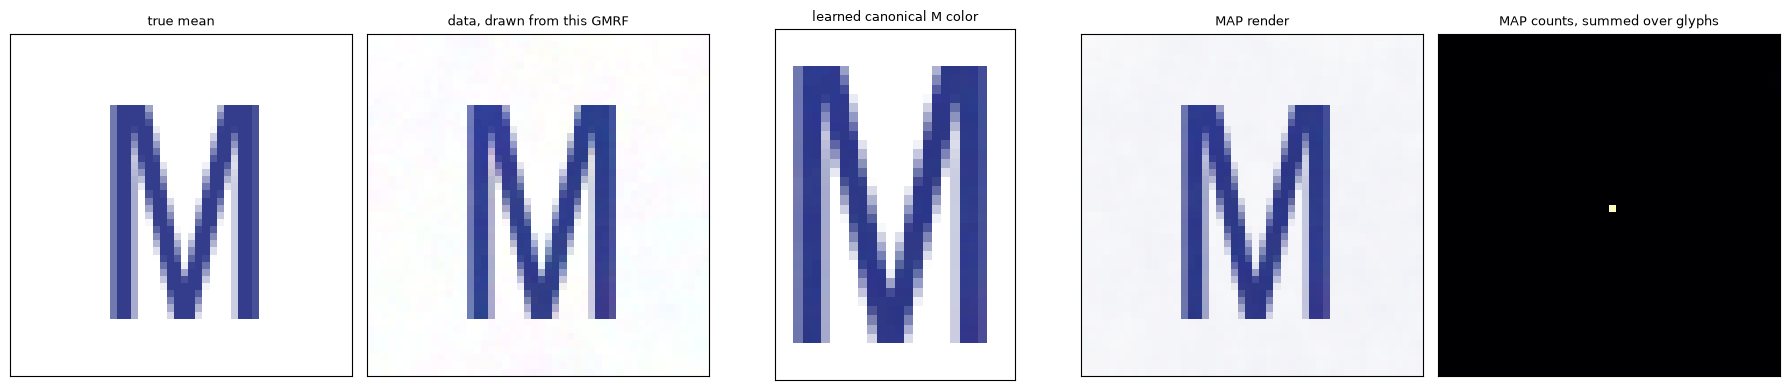

In [7]:
recovered = render(counts_map, color_field_map)
color_preview_map = glyph_color_preview(
    color_field_map, [true_glyph_index]
)
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
show(ax[0], np.clip(mrf.mean, 0, 1), "true mean")
show(ax[1], np.clip(data, 0, 1), "data, drawn from this GMRF")
show(ax[2], color_preview_map, "learned canonical M color")
show(ax[3], np.clip(recovered.over_background(), 0, 1), "MAP render")
show(
    ax[4], np.asarray(counts_map.sum(-1)),
    "MAP counts, summed over glyphs", cmap="magma",
)
fig.tight_layout()


## 3. Full Gamma--Normal MAP recovery with a shared glyph texture

Nothing about the glyph or clutter color is supplied to this fit. The clutter
is not rendered at all: it remains in the observation residual and can be
downweighted by the Gamma--Normal likelihood. The conditional mean instead
contains a proper $8\times8\times3$ coarse paper GMRF and a rendered glyph
layer. All 36 dictionary glyphs and all their occurrences share one canonical
RGB texture field

$$
c(u)=\operatorname{sigmoid}(m+r_u),\qquad
c_s(p)=c(T_s^{-1}p),
$$

where $m\in\mathbb R^3$ is a global RGB logit and
$r\in\mathbb R^{H_g\times W_g\times3}$ is a zero-mean canonical residual.
The present $T_s$ is an on-grid translation; a later warp would require
bilinear sampling. Each glyph's alpha bitmap merely reveals a different subset
of the same field. In particular, there are not 36 separate texture fields.

The texture prior is a normalized, proper second-order GMRF. With $\mathcal L$
the four-neighbour graph Laplacian on the entire canonical rectangle,

$$
A_g=\eta_g I+\rho_g\mathcal L,\qquad
p_\theta(r)=\mathcal N\!\left(r;0,(A_g^\top A_g)^{-1}\otimes I_3\right).
$$

Thus $-\log p_\theta(r)$ contains
$\tfrac12\lVert A_g r\rVert^2$, which penalizes curvature rather than only
first differences. The positive $\eta_g I$ term removes the Laplacian null
space, and `SecondOrderGaussianMrf.log_prob` includes the exact determinant.

Fine-scale dots and the curved distractor are handled by one latent precision
shared by the three color channels at each pixel. If $n_p(z)$ is the composited
`Layer.count`, then

$$
\begin{aligned}
\nu_p &= n_p(z)+1,\\
\lambda_p\mid z
&\sim \operatorname{Gamma}\left(\frac{\nu_p}{2},
                                  \frac{\nu_p}{2}\right),\\
Q(z)&=\tau I+\kappa\mathcal L(n(z)),\\
x\mid z,\lambda
&\sim \mathcal N\left(
  \mu(z),
  [\Lambda^{1/2}Q(z)\Lambda^{1/2}\otimes I_3]^{-1}
\right),
\end{aligned}
$$

where $\Lambda=\operatorname{diag}(\lambda_1,\ldots,\lambda_{HW})$.
`LocallyScaledGaussianMrf` evaluates this normalized conditional density by the
change of variables

$$
y=\mu+\Lambda^{1/2}(x-\mu),
$$

so it reuses the sparse quadratic form, exact block-Cholesky log determinant,
and conjugate-gradient sampler of `PartitionedGaussianMrf`; no dense precision
matrix is formed. For $C=3$ color channels, the corresponding log density is

$$
\log p_\theta(x\mid z,\lambda)
=\log p_\theta(y\mid z)
 +\frac C2\sum_p\log\lambda_p.
$$

With $a_p=b_p=\nu_p/2$, the normalized local-scale prior included in MAP is

$$
\log p_\theta(\lambda\mid z)
=\sum_p\left[
  a_p\log b_p-\log\Gamma(a_p)
 +(a_p-1)\log\lambda_p-b_p\lambda_p
\right].
$$

Let $f$ be the coarse paper residual and $\ell_b$ its RGB logit. The rendered
mean is $\mu_\theta(a,m,r,f,\ell_b)$, and the continuous count relaxation
has the normalized sparsity prior $p_\theta(a)=\prod_{s,k}
\operatorname{Exponential}(a_{s,k};\rho_a)$. Collecting every inferred
quantity as $z=(a,m,r,f,\ell_b,\lambda)$, the full joint MAP target is

$$
\gamma_\theta(z;x)
=p_\theta(x\mid a,m,r,f,\ell_b,\lambda)\,
 p_\theta(\lambda\mid n(a))\,p_\theta(a)\,p_\theta(m)\,
 p_\theta(r)\,p_\theta(f)\,p_\theta(\ell_b).
$$

Section 3 optimizes every component of $z$ jointly. The later support pruning
is only an active-set approximation to the continuous count MAP; it does not
freeze any appearance, paper, or precision variable. The optimizer stores an
unconstrained coordinate $s_p$ and evaluates
$\lambda_p=\operatorname{softplus}(s_p)+\epsilon$. It maximizes the density with
respect to the Gamma variate $\lambda_p$ itself, so the softplus is only an
optimization coordinate and contributes no change-of-variables Jacobian to
$\gamma_\theta$.


In [8]:
COARSE_SHAPE_REAL = (8, 8)
COLOR_LOGIT_SCALE_REAL = 2.0
COUNT_RATE_REAL = 25.0
COUNT_THRESHOLD_REAL = 0.02
GLYPH_TEXTURE_BOND_PRECISION_REAL = 4.0
GLYPH_TEXTURE_ELEMENT_PRECISION_REAL = 1.0
KAPPA_REAL = 100.0
PAPER_COLOR_LOC_REAL = jnp.asarray([0.94, 0.95, 0.98])
PAPER_FIELD_BOND_PRECISION_REAL = 1.0
PAPER_FIELD_ELEMENT_PRECISION_REAL = 0.25
PAPER_LOGIT_LOC_REAL = (
    jnp.log(PAPER_COLOR_LOC_REAL) - jnp.log1p(-PAPER_COLOR_LOC_REAL)
)
PAPER_LOGIT_SCALE_REAL = 0.35
STEPS_INITIAL_REAL = 1500
STEPS_REFINE_REAL = 500
TAU_REAL = 50.0

real_data = jnp.asarray(plt.imread("data/examples/0002_J8.png"))

def local_scale_background_from(parameters):
    field = jax.image.resize(
        parameters["paper_field"], real_data.shape, method="cubic"
    )
    background = jax.nn.sigmoid(parameters["paper_logit"] + field)
    return background, field


def local_scale_paper_distribution():
    return CompleteGaussianMrf(
        jnp.zeros((*COARSE_SHAPE_REAL, real_data.shape[-1])),
        PAPER_FIELD_ELEMENT_PRECISION_REAL * jnp.ones(COARSE_SHAPE_REAL),
        jnp.asarray(PAPER_FIELD_BOND_PRECISION_REAL),
    )


def local_scale_background_log_prior(parameters):
    field_log_prob = local_scale_paper_distribution().log_prob(
        parameters["paper_field"]
    )
    logit_log_prob = dist.Normal(
        PAPER_LOGIT_LOC_REAL, PAPER_LOGIT_SCALE_REAL
    ).log_prob(parameters["paper_logit"]).sum()
    return field_log_prob + logit_log_prob


def local_scale_color_field_from(parameters):
    return glyph_color_field(
        parameters["color_logit"], parameters["color_texture"]
    )


def local_scale_texture_distribution():
    # Construct inside a trace so lazy sparse properties cannot cache tracers.
    return SecondOrderGaussianMrf.from_coverage(
        jnp.ones(KERNEL.shape[:2]),
        GLYPH_TEXTURE_ELEMENT_PRECISION_REAL * jnp.ones(KERNEL.shape[:2]),
        GLYPH_TEXTURE_BOND_PRECISION_REAL,
        channels=real_data.shape[-1],
    )


def local_scale_color_log_prior(parameters):
    logit_log_prob = dist.Normal(
        0.0, COLOR_LOGIT_SCALE_REAL
    ).log_prob(parameters["color_logit"]).sum()
    texture_log_prob = local_scale_texture_distribution().log_prob(
        parameters["color_texture"]
    )
    return logit_log_prob + texture_log_prob


def local_scale_composite(parameters, support):
    background, _ = local_scale_background_from(parameters)
    color_field = local_scale_color_field_from(parameters)
    counts = parameters["counts"] * support
    glyph = render(counts, color_field)
    return glyph @ Layer.straight(background)


def local_scale_degrees_of_freedom(composite):
    return composite.count.astype(real_data.dtype) + 1.0


def local_scale_observation_model(composite, observation=None):
    degrees_of_freedom = local_scale_degrees_of_freedom(composite)
    local_precision = numpyro.sample(
        "local_precision",
        dist.Gamma(
            0.5 * degrees_of_freedom,
            0.5 * degrees_of_freedom,
        ).to_event(2),
    )
    likelihood = LocallyScaledGaussianMrf(
        composite,
        TAU_REAL * jnp.ones(real_data.shape[:-1]),
        KAPPA_REAL,
        local_precision,
    )
    return numpyro.sample("x", likelihood, obs=observation)


def local_scale_precision_from(parameters):
    return jax.nn.softplus(
        parameters["local_precision_unconstrained"]
    ) + 1e-6


sampled Gamma precision quantiles: [0.    0.016 0.453 2.758 6.551]


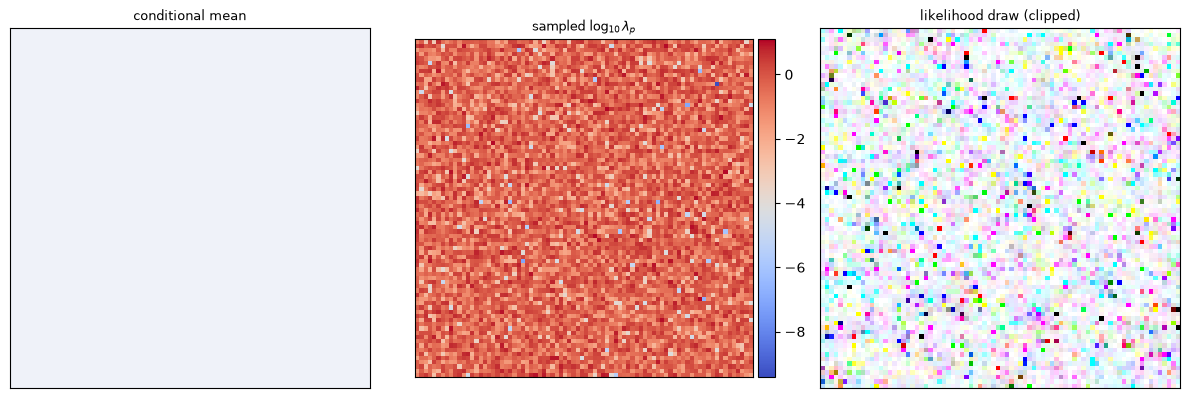

In [9]:
local_scale_initial_parameters = {
    "color_logit": jnp.zeros((real_data.shape[-1],)),
    "color_texture": jnp.zeros(
        local_scale_texture_distribution().shape()
    ),
    "counts": jnp.zeros((*real_data.shape[:-1], K)),
    "local_precision_unconstrained": jnp.full(
        real_data.shape[:-1], jnp.log(jnp.expm1(1.0))
    ),
    "paper_field": jnp.zeros((*COARSE_SHAPE_REAL, real_data.shape[-1])),
    "paper_logit": PAPER_LOGIT_LOC_REAL,
}
local_scale_initial_support = jnp.ones_like(
    local_scale_initial_parameters["counts"]
)
local_scale_prior_composite = local_scale_composite(
    local_scale_initial_parameters, local_scale_initial_support
)
local_scale_prior_trace = numpyro.handlers.trace(
    numpyro.handlers.seed(local_scale_observation_model, rng_seed=31)
).get_trace(local_scale_prior_composite)
local_scale_prior_precision = local_scale_prior_trace[
    "local_precision"
]["value"]
local_scale_prior_sample = local_scale_prior_trace["x"]["value"]

print(
    "sampled Gamma precision quantiles:",
    np.quantile(
        np.asarray(local_scale_prior_precision),
        [0.01, 0.1, 0.5, 0.9, 0.99],
    ).round(3),
)
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
show(
    axes[0], local_scale_prior_composite.over_background(),
    "conditional mean",
)
img = show(
    axes[1], jnp.log10(local_scale_prior_precision),
    r"sampled $\log_{10}\lambda_p$", cmap="coolwarm",
)
colorbar(axes[1], figure, img)
show(
    axes[2], jnp.clip(local_scale_prior_sample, 0.0, 1.0),
    "likelihood draw (clipped)",
)
figure.tight_layout()


In [10]:
def local_scale_objective(parameters, support):
    color_log_prior = local_scale_color_log_prior(parameters)
    composite = local_scale_composite(parameters, support)
    counts = parameters["counts"] * support
    counts_log_prior = (
        # The normalized Exponential density has this finite limit at zero.
        counts.size * jnp.log(COUNT_RATE_REAL)
        - COUNT_RATE_REAL * counts.sum()
    )
    degrees_of_freedom = local_scale_degrees_of_freedom(composite)
    local_precision = local_scale_precision_from(parameters)
    likelihood = LocallyScaledGaussianMrf(
        composite,
        TAU_REAL * jnp.ones(real_data.shape[:-1]),
        KAPPA_REAL,
        local_precision,
    )
    local_precision_log_prior = dist.Gamma(
        0.5 * degrees_of_freedom,
        0.5 * degrees_of_freedom,
    ).log_prob(local_precision).sum()
    paper_log_prior = local_scale_background_log_prior(parameters)
    return -(
        color_log_prior
        + counts_log_prior
        + likelihood.log_prob(real_data)
        + local_precision_log_prior
        + paper_log_prior
    )


local_scale_parameter_labels = {
    "color_logit": "appearance",
    "color_texture": "appearance",
    "counts": "counts",
    "local_precision_unconstrained": "precision",
    "paper_field": "background",
    "paper_logit": "background",
}
local_scale_parameters = local_scale_initial_parameters
local_scale_optimizer = optax.multi_transform(
    {
        "appearance": optax.adam(0.01),
        "background": optax.adam(0.01),
        "counts": optax.adam(0.001),
        "precision": optax.adam(0.005),
    },
    local_scale_parameter_labels,
)
local_scale_optimizer_state = local_scale_optimizer.init(
    local_scale_parameters
)


@jax.jit
def local_scale_step(parameters, optimizer_state, support):
    value, gradients = jax.value_and_grad(local_scale_objective)(
        parameters, support
    )
    updates, optimizer_state = local_scale_optimizer.update(
        gradients, optimizer_state
    )
    parameters = optax.apply_updates(parameters, updates)
    parameters["color_logit"] = jnp.clip(
        parameters["color_logit"], -12.0, 12.0
    )
    parameters["color_texture"] = jnp.clip(
        parameters["color_texture"], -6.0, 6.0
    )
    parameters["counts"] = jnp.maximum(parameters["counts"], 0.0)
    parameters["local_precision_unconstrained"] = jnp.clip(
        parameters["local_precision_unconstrained"], -20.0, 20.0
    )
    return parameters, optimizer_state, value


In [11]:
local_scale_support = jnp.ones_like(local_scale_parameters["counts"])
for index in range(STEPS_INITIAL_REAL):
    local_scale_parameters, local_scale_optimizer_state, local_scale_value = (
        local_scale_step(
            local_scale_parameters,
            local_scale_optimizer_state,
            local_scale_support,
        )
    )
    if index % 100 == 0:
        print(
            f"  initial {index:4d}  objective {float(local_scale_value):12.2f}"
        )

local_scale_support = (
    local_scale_parameters["counts"] >= COUNT_THRESHOLD_REAL
)
local_scale_parameters["counts"] = (
    local_scale_parameters["counts"] * local_scale_support
)
local_scale_optimizer_state = local_scale_optimizer.init(
    local_scale_parameters
)
for index in range(STEPS_REFINE_REAL):
    local_scale_parameters, local_scale_optimizer_state, local_scale_value = (
        local_scale_step(
            local_scale_parameters,
            local_scale_optimizer_state,
            local_scale_support,
        )
    )
    if index % 100 == 0:
        print(
            f"  refine  {index:4d}  objective {float(local_scale_value):12.2f}"
        )


  initial    0  objective   -745293.70
  initial  100  objective   -740747.55
  initial  200  objective   -758487.16
  initial  300  objective   -765707.62
  initial  400  objective   -769115.45
  initial  500  objective   -771021.17
  initial  600  objective   -771896.92
  initial  700  objective   -772581.44
  initial  800  objective   -773107.70
  initial  900  objective   -773546.13
  initial 1000  objective   -773981.32
  initial 1100  objective   -774353.85
  initial 1200  objective   -774609.32
  initial 1300  objective   -774844.40
  initial 1400  objective   -775000.77
  refine     0  objective   -773174.63
  refine   100  objective   -775272.87
  refine   200  objective   -775681.83
  refine   300  objective   -775897.16
  refine   400  objective   -776028.26


    8_42 at (31, 14)  0.1190
    J_42 at (32, 53)  0.0955
    J_42 at (32, 52)  0.0539
    8_42 at (31, 13)  0.0521
    8_42 at (32, 14)  0.0448
    J_42 at (33, 53)  0.0419
    8_42 at (31, 15)  0.0380
    J_42 at (31, 53)  0.0302
    J_42 at (33, 52)  0.0261
    J_42 at (32, 54)  0.0261
  active dictionary coefficients: 16
    8_42 alpha-weighted color: [0.083 0.327 0.275]
    J_42 alpha-weighted color: [0.082 0.326 0.274]
  glyph mass: 0.651
  mean paper color: [0.941 0.953 0.984]
  background precision quantiles: [0.031 0.836 1.999 2.   ]
  glyph precision quantiles: [0.317 0.695 0.852 1.145]
  ordinary reconstruction RMSE: 0.1011
  precision-weighted RMSE: 0.0292


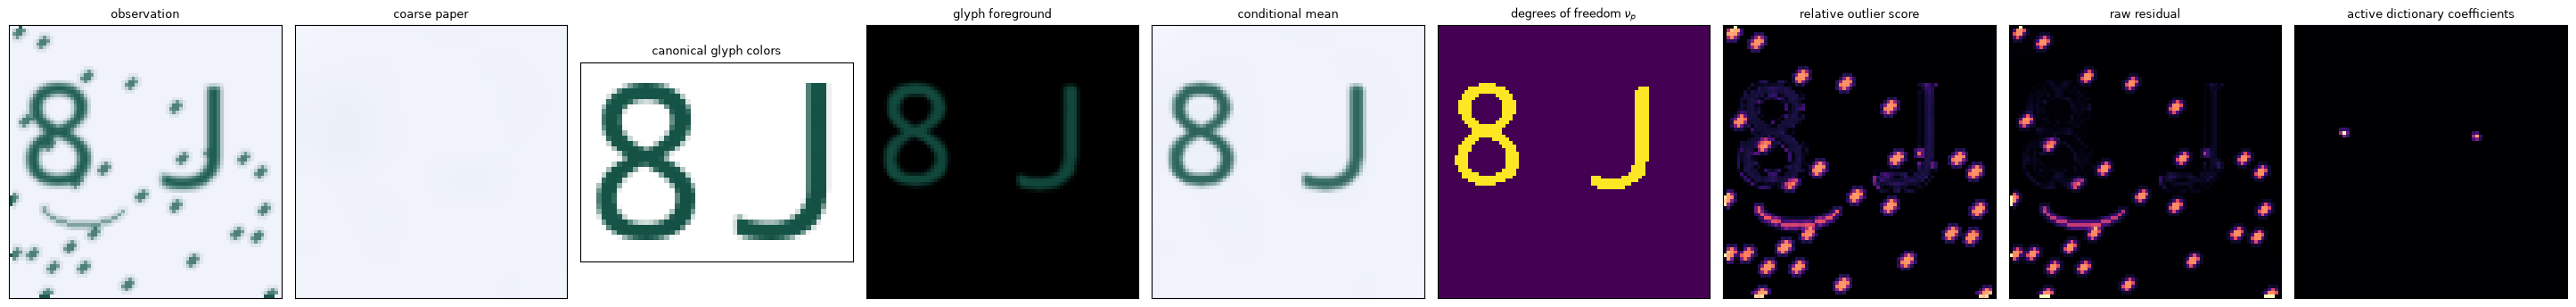

In [12]:
local_scale_background_map, local_scale_field_map = (
    local_scale_background_from(local_scale_parameters)
)
local_scale_color_field_map = local_scale_color_field_from(
    local_scale_parameters
)
local_scale_composite_map = local_scale_composite(
    local_scale_parameters, local_scale_support
)
local_scale_counts_map = (
    local_scale_parameters["counts"] * local_scale_support
)
local_scale_degrees_map = local_scale_degrees_of_freedom(
    local_scale_composite_map
)
local_scale_glyph_map = render(
    local_scale_counts_map, local_scale_color_field_map
)
local_scale_map = local_scale_precision_from(local_scale_parameters)
local_scale_reconstruction_map = local_scale_composite_map.over_background()
local_scale_residual_map = real_data - local_scale_reconstruction_map
local_scale_robust_residual_map = (
    jnp.sqrt(local_scale_map)[..., None] * local_scale_residual_map
)
local_scale_scale_baseline_map = (
    local_scale_degrees_map + real_data.shape[-1] - 2.0
) / local_scale_degrees_map

local_scale_background_values = np.asarray(local_scale_map)[
    np.asarray(local_scale_degrees_map) == 1.0
]
local_scale_flat = np.asarray(local_scale_counts_map).ravel()
local_scale_glyph_values = np.asarray(local_scale_map)[
    np.asarray(local_scale_degrees_map) > 1.0
]
local_scale_order = np.argsort(local_scale_flat)[::-1][:10]
local_scale_rmse = jnp.sqrt(jnp.mean(local_scale_residual_map**2))
local_scale_robust_rmse = jnp.sqrt(
    jnp.mean(local_scale_robust_residual_map**2)
)

local_scale_active_glyph_indices = sorted(
    {
        np.unravel_index(rank, local_scale_counts_map.shape)[-1]
        for rank in np.flatnonzero(np.asarray(local_scale_support).ravel())
    }
)
local_scale_color_preview_map = glyph_color_preview(
    local_scale_color_field_map, local_scale_active_glyph_indices
)

for rank in local_scale_order:
    y, x, k = np.unravel_index(rank, local_scale_counts_map.shape)
    print(
        f"  {GLYPHS[k]:>6} at ({y:2d}, {x:2d})  "
        f"{local_scale_flat[rank]:.4f}"
    )
print(f"  active dictionary coefficients: {int(local_scale_support.sum())}")
for glyph_index in local_scale_active_glyph_indices:
    color_mean = glyph_color_mean(
        local_scale_color_field_map, glyph_index
    )
    print(
        f"  {GLYPHS[glyph_index]:>6} alpha-weighted color: "
        f"{np.asarray(color_mean).round(3)}"
    )
print(f"  glyph mass: {float(local_scale_counts_map.sum()):.3f}")
print(
    "  mean paper color: "
    f"{np.asarray(local_scale_background_map.mean((0, 1))).round(3)}"
)
print(
    "  background precision quantiles: "
    f"{np.quantile(local_scale_background_values, [0.01, 0.1, 0.5, 0.9]).round(3)}"
)
if local_scale_glyph_values.size:
    print(
        "  glyph precision quantiles: "
        f"{np.quantile(local_scale_glyph_values, [0.01, 0.1, 0.5, 0.9]).round(3)}"
    )
print(f"  ordinary reconstruction RMSE: {float(local_scale_rmse):.4f}")
print(f"  precision-weighted RMSE: {float(local_scale_robust_rmse):.4f}")

figure, axes = plt.subplots(1, 9, figsize=(29, 4))
show(axes[0], real_data, "observation")
show(axes[1], local_scale_background_map, "coarse paper")
show(axes[2], local_scale_color_preview_map, "canonical glyph colors")
show(
    axes[3], local_scale_glyph_map.image, "glyph foreground",
    vmin=0.0, vmax=1.0,
)
show(
    axes[4], jnp.clip(local_scale_reconstruction_map, 0.0, 1.0),
    "conditional mean",
)
show(
    axes[5], local_scale_degrees_map, r"degrees of freedom $\nu_p$",
    cmap="viridis", vmin=1.0,
)
show(
    axes[6], jnp.maximum(
        jnp.log10(local_scale_scale_baseline_map / local_scale_map), 0.0
    ), "relative outlier score", cmap="magma", vmin=0.0,
)
show(
    axes[7], jnp.linalg.norm(local_scale_residual_map, axis=-1),
    "raw residual", cmap="magma", vmin=0.0,
)
show(
    axes[8], local_scale_counts_map.sum(-1),
    "active dictionary coefficients", cmap="magma", vmin=0.0,
)
figure.tight_layout()


### Reading the learned colors and Gamma precisions

The fit begins at the prior mode: a neutral $m=0$ and $r=0$, corresponding
to an RGB value of $(0.5,0.5,0.5)$. Neither the glyph's teal color nor the
clutter's teal color is used for initialization. The fitted appearance is no
longer one RGB vector. The `canonical glyph colors`
panel shows the same $H_g\times W_g\times3$ latent field through each active
glyph's alpha mask; the printed alpha-weighted means differ only because those
masks expose different canonical pixels. The baseline $m$ absorbs the overall
color, while the second-order residual $r$ pays a curvature penalty. Keeping
those roles separate matters: forcing an overall color shift through the
residual would charge roughly one element-precision penalty per canonical
pixel, whereas a three-dimensional baseline can shift it directly. The texture
density itself is evaluated by `SecondOrderGaussianMrf.log_prob`, including its
normalizer; it is not merely an unnormalized smoothness energy.

The Gamma variables are part of the generative model and of the joint MAP
target. The prior has $\mathbb E[\lambda_p\mid\nu_p]=1$, but its joint posterior
mode depends on the three-channel residual and the GMRF bonds. For a locally
negligible residual with no effective bond contribution, the approximate mode is

$$
\widehat\lambda_p
\approx\frac{\nu_p+3-2}{\nu_p}
=\frac{\nu_p+1}{\nu_p}.
$$

The diagnostic therefore plots precision relative to this count-specific
baseline rather than treating every $\lambda_p<1$ as an outlier. Small relative
precision marks observations that the likelihood downweights instead of forcing
the coarse paper or glyph mean to reconstruct them.


## 4. Gamma-Normal recovery without a coarse background latent

This is a direct ablation of Section 3.  It fixes the paper image to the
constant $b_0=(0.94,0.95,0.98)$ and removes both the global paper logit and
the $8\times8\times3$ coarse paper GMRF.  The remaining latents are the
relaxed glyph counts $a$, shared canonical glyph color $(m,r)$, and local
Gamma precisions $\lambda$.  Thus

$$
\mu_\theta(z)=
\operatorname{over}(\operatorname{render}(a,m,r),b_0),
$$

and, writing $D(\lambda)=\operatorname{diag}(\sqrt{\lambda})$,

$$
\begin{aligned}
\lambda_p\mid z
&\sim\operatorname{Gamma}(\nu_p(z)/2,\nu_p(z)/2),\\
x\mid z,\lambda
&\sim\mathcal N\!\left(
\mu_\theta(z),
[D(\lambda)Q(z)D(\lambda)\otimes I_C]^{-1}
\right),\\
\gamma_\theta(z,\lambda;x)
&=p_\theta(x\mid z,\lambda)
p_\theta(\lambda\mid z)p_\theta(a)p_\theta(m)p_\theta(r).
\end{aligned}
$$

The optimizer starts from zero counts and unit local precisions over the full
dictionary, then uses the same support threshold and refinement schedule as
Section 3.  Keeping its count penalty and all likelihood hyperparameters fixed
isolates the removal of the background latent.


In [13]:
NO_BACKGROUND_STEPS_INITIAL_REAL = 1500
NO_BACKGROUND_STEPS_REFINE_REAL = 500
NO_BACKGROUND_THRESHOLD_REAL = COUNT_THRESHOLD_REAL


def no_background_composite(parameters, support):
    color_field = local_scale_color_field_from(parameters)
    counts = parameters["counts"] * support
    glyph = render(counts, color_field)
    background = jnp.broadcast_to(
        PAPER_COLOR_LOC_REAL, glyph.image.shape
    )
    return glyph @ Layer.straight(background)


def no_background_objective(parameters, support):
    color_log_prior = local_scale_color_log_prior(parameters)
    composite = no_background_composite(parameters, support)
    counts = parameters["counts"] * support
    counts_log_prior = (
        counts.size * jnp.log(COUNT_RATE_REAL)
        - COUNT_RATE_REAL * counts.sum()
    )
    degrees_of_freedom = local_scale_degrees_of_freedom(composite)
    local_precision = local_scale_precision_from(parameters)
    likelihood = LocallyScaledGaussianMrf(
        composite,
        TAU_REAL * jnp.ones(real_data.shape[:-1]),
        KAPPA_REAL,
        local_precision,
    )
    local_precision_log_prior = dist.Gamma(
        0.5 * degrees_of_freedom,
        0.5 * degrees_of_freedom,
    ).log_prob(local_precision).sum()
    return -(
        color_log_prior
        + counts_log_prior
        + likelihood.log_prob(real_data)
        + local_precision_log_prior
    )


no_background_color_initial_real = jnp.clip(
    jnp.quantile(real_data, 0.05, axis=(0, 1)), 1e-4, 1.0 - 1e-4
)
no_background_parameter_labels_real = {
    "color_logit": "appearance",
    "color_texture": "appearance",
    "counts": "counts",
    "local_precision_unconstrained": "precision",
}
no_background_parameters_real = {
    "color_logit": (
        jnp.log(no_background_color_initial_real)
        - jnp.log1p(-no_background_color_initial_real)
    ),
    "color_texture": jnp.zeros(GLYPH_COLOR_PRIOR.shape()),
    "counts": jnp.zeros((*real_data.shape[:-1], K)),
    "local_precision_unconstrained": jnp.full(
        real_data.shape[:-1], jnp.log(jnp.expm1(1.0))
    ),
}
no_background_support_real = jnp.ones_like(
    no_background_parameters_real["counts"]
)
no_background_optimizer_real = optax.multi_transform(
    {
        "appearance": optax.adam(0.01),
        "counts": optax.adam(0.001),
        "precision": optax.adam(0.005),
    },
    no_background_parameter_labels_real,
)
no_background_optimizer_state_real = no_background_optimizer_real.init(
    no_background_parameters_real
)


@jax.jit
def no_background_step(parameters, optimizer_state, support):
    value, gradients = jax.value_and_grad(no_background_objective)(
        parameters, support
    )
    updates, optimizer_state = no_background_optimizer_real.update(
        gradients, optimizer_state
    )
    parameters = optax.apply_updates(parameters, updates)
    parameters["color_logit"] = jnp.clip(
        parameters["color_logit"], -12.0, 12.0
    )
    parameters["color_texture"] = jnp.clip(
        parameters["color_texture"], -6.0, 6.0
    )
    parameters["counts"] = jnp.maximum(
        parameters["counts"], 0.0
    )
    parameters["local_precision_unconstrained"] = jnp.clip(
        parameters["local_precision_unconstrained"], -20.0, 20.0
    )
    return parameters, optimizer_state, value


for index in range(NO_BACKGROUND_STEPS_INITIAL_REAL):
    (
        no_background_parameters_real,
        no_background_optimizer_state_real,
        no_background_value_real,
    ) = no_background_step(
        no_background_parameters_real,
        no_background_optimizer_state_real,
        no_background_support_real,
    )
    if index % 100 == 0:
        print(
            f"  initial {index:4d}  objective "
            f"{float(no_background_value_real):12.2f}"
        )

no_background_support_real = (
    no_background_parameters_real["counts"]
    >= NO_BACKGROUND_THRESHOLD_REAL
)
no_background_parameters_real["counts"] = (
    no_background_parameters_real["counts"]
    * no_background_support_real
)
no_background_optimizer_state_real = no_background_optimizer_real.init(
    no_background_parameters_real
)
for index in range(NO_BACKGROUND_STEPS_REFINE_REAL):
    (
        no_background_parameters_real,
        no_background_optimizer_state_real,
        no_background_value_real,
    ) = no_background_step(
        no_background_parameters_real,
        no_background_optimizer_state_real,
        no_background_support_real,
    )
    if index % 100 == 0:
        print(
            f"  refine  {index:4d}  objective "
            f"{float(no_background_value_real):12.2f}"
        )


  initial    0  objective   -745363.20
  initial  100  objective   -736088.12
  initial  200  objective   -757276.27
  initial  300  objective   -765251.94
  initial  400  objective   -768693.07
  initial  500  objective   -770341.26
  initial  600  objective   -771203.90
  initial  700  objective   -771944.39
  initial  800  objective   -772617.08
  initial  900  objective   -773158.37
  initial 1000  objective   -773582.43
  initial 1100  objective   -773957.61
  initial 1200  objective   -774245.47
  initial 1300  objective   -774485.56
  initial 1400  objective   -774670.37
  refine     0  objective   -774471.86
  refine   100  objective   -775468.65
  refine   200  objective   -775851.61
  refine   300  objective   -776030.80
  refine   400  objective   -776135.05


    8_42 at (31, 14)  0.1189
    J_42 at (32, 53)  0.0943
    J_42 at (32, 52)  0.0543
    J_42 at (33, 53)  0.0423
    8_42 at (31, 13)  0.0387
    8_42 at (31, 15)  0.0373
    8_42 at (32, 14)  0.0336
    J_42 at (31, 53)  0.0302
    8_42 at (30, 14)  0.0277
    J_42 at (32, 54)  0.0259
  active dictionary coefficients: 18
  glyph mass: 0.670
  ordinary reconstruction RMSE: 0.0989
  precision-weighted RMSE: 0.0270
  background precision quantiles: [0.03  0.809 1.996 1.997]
  glyph precision quantiles: [0.314 0.662 0.802 1.158]


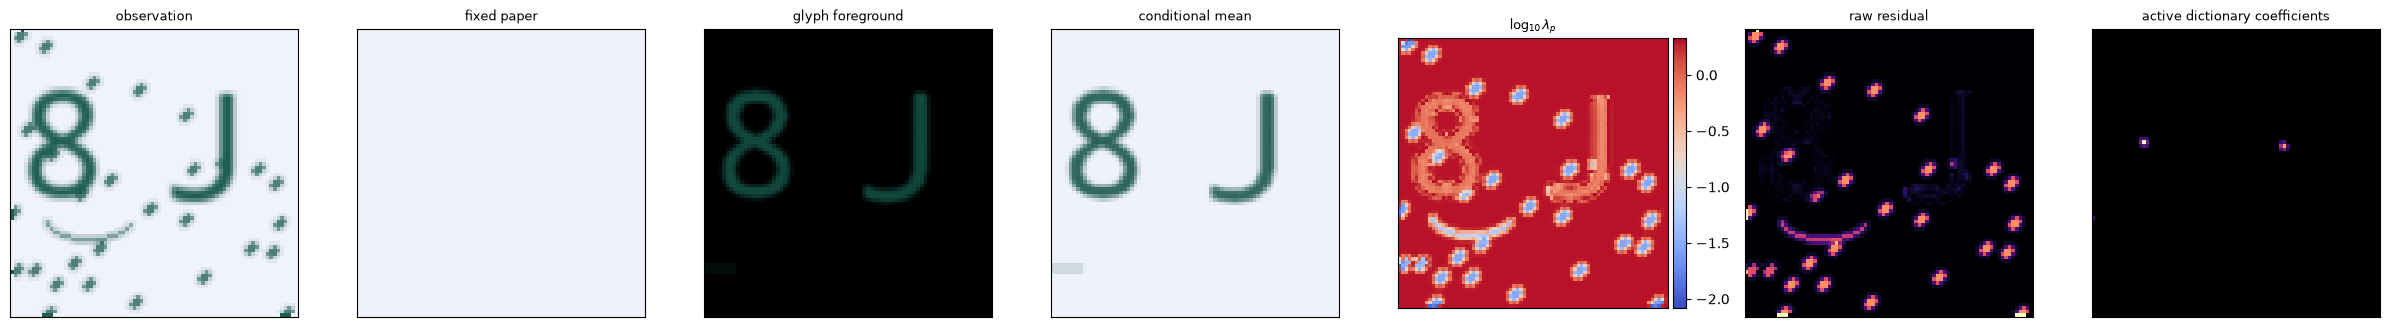

In [14]:
no_background_color_field_real = local_scale_color_field_from(
    no_background_parameters_real
)
no_background_composite_real = no_background_composite(
    no_background_parameters_real, no_background_support_real
)
no_background_counts_real = (
    no_background_parameters_real["counts"]
    * no_background_support_real
)
no_background_degrees_real = local_scale_degrees_of_freedom(
    no_background_composite_real
)
no_background_glyph_real = render(
    no_background_counts_real, no_background_color_field_real
)
no_background_precision_real = local_scale_precision_from(
    no_background_parameters_real
)
no_background_reconstruction_real = (
    no_background_composite_real.over_background()
)
no_background_residual_real = (
    real_data - no_background_reconstruction_real
)
no_background_robust_residual_real = (
    jnp.sqrt(no_background_precision_real)[..., None]
    * no_background_residual_real
)

no_background_background_precision_real = np.asarray(
    no_background_precision_real
)[np.asarray(no_background_degrees_real) == 1.0]
no_background_flat_real = np.asarray(no_background_counts_real).ravel()
no_background_glyph_precision_real = np.asarray(
    no_background_precision_real
)[np.asarray(no_background_degrees_real) > 1.0]
no_background_order_real = np.argsort(
    no_background_flat_real
)[::-1][:10]
for rank in no_background_order_real:
    y, x, glyph_index = np.unravel_index(
        rank, no_background_counts_real.shape
    )
    print(
        f"  {GLYPHS[glyph_index]:>6} at ({y:2d}, {x:2d})  "
        f"{no_background_flat_real[rank]:.4f}"
    )
print(
    "  active dictionary coefficients: "
    f"{int(no_background_support_real.sum())}"
)
print(f"  glyph mass: {float(no_background_counts_real.sum()):.3f}")
print(
    "  ordinary reconstruction RMSE: "
    f"{float(jnp.sqrt(jnp.mean(no_background_residual_real**2))):.4f}"
)
print(
    "  precision-weighted RMSE: "
    f"{float(jnp.sqrt(jnp.mean(
        no_background_robust_residual_real**2
    ))):.4f}"
)
print(
    "  background precision quantiles: "
    f"{np.quantile(
        no_background_background_precision_real,
        [0.01, 0.1, 0.5, 0.9],
    ).round(3)}"
)
if no_background_glyph_precision_real.size:
    print(
        "  glyph precision quantiles: "
        f"{np.quantile(
            no_background_glyph_precision_real,
            [0.01, 0.1, 0.5, 0.9],
        ).round(3)}"
    )

figure, axes = plt.subplots(1, 7, figsize=(24, 4))
show(axes[0], real_data, "observation")
show(
    axes[1], jnp.broadcast_to(PAPER_COLOR_LOC_REAL, real_data.shape),
    "fixed paper",
)
show(axes[2], no_background_glyph_real.image, "glyph foreground")
show(
    axes[3], jnp.clip(no_background_reconstruction_real, 0.0, 1.0),
    "conditional mean",
)
img = show(
    axes[4], jnp.log10(no_background_precision_real),
    r"$\log_{10}\lambda_p$", cmap="coolwarm",
)
colorbar(axes[4], figure, img)
show(
    axes[5], jnp.linalg.norm(no_background_residual_real, axis=-1),
    "raw residual", cmap="magma", vmin=0.0,
)
show(
    axes[6], no_background_counts_real.sum(-1),
    "active dictionary coefficients", cmap="magma", vmin=0.0,
)
figure.tight_layout()

### Reading the no-background ablation

This section should be read against Section 3: whether it recovers `J8`, how
many count coefficients survive, and whether smooth paper variation appears
as a broad low-precision field directly measure what the coarse background
latent was buying us.

In a fresh blank-start run, the no-background model recovers `8_42` at
$(31,14)$ and `J_42` at $(32,53)$.  It retains 18 coefficients with total
glyph mass $0.670$, ordinary RMSE $0.0989$, and precision-weighted RMSE
$0.0270$.  The corresponding coarse-background run retained 16 coefficients
with mass $0.648$ and RMSEs $0.1012$ and $0.0291$.  The two fits are therefore
essentially equivalent on this image; fixing the paper even gives slightly
lower reconstruction errors, at the cost of two additional coefficients.

This does not establish that the paper field is generally unnecessary.  The
fixed color was already nearly identical to the fitted mean paper color, and
the local Gamma variables can absorb remaining mismatches pixel by pixel.
Images with coherent gradients or different paper colors remain the important
counterexample to test.
